## 0. Source Data
https://clearinghouse.isgs.illinois.edu/data/elevation/illinois-height-modernization-ilhmp

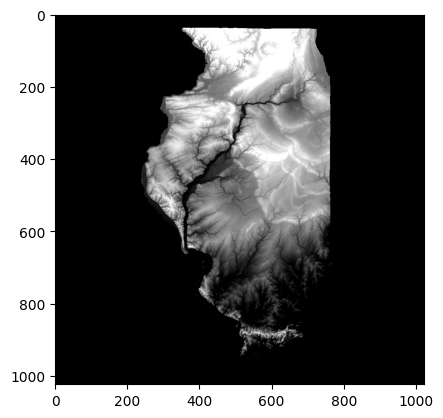

In [1]:
import matplotlib.pyplot as plt 

dem = plt.imread('IL_Statewide_Lidar_DEM_WGS.png')[:,:,0]
plt.imshow(dem, cmap='gray', vmin=0, vmax=1)

## 1. Computer Graphics Primer

### 1.0. Vectors
- Dot product of unit vectors: $\vec{u}\cdot\vec{v} = u_xv_x + u_yv_y + u_zv_z = cos\theta$
- Cross product of unit vectors $\vec{u}\times\vec{v} = (u_yv_z-u_zv_y)\vec{e}_x + (u_zv_x-u_xv_z)\vec{e}_y + (u_xv_y-u_yv_x)\vec{e}_z = sin\theta\ \vec{n}$

### 1.1. Surfaces
Given a surface $S(x, y) = (x, y, f(x, y))^\top$. The tangent vectors are 
$$\vec{u}(x,y) = \frac{\partial S}{\partial x}(x,y) = \left(1, 0, \frac{\partial f}{\partial x}(x, y)\right)^\top, \quad
\vec{v}(x,y) = \frac{\partial S}{\partial y}(x,y) = \left(0, 1, \frac{\partial f}{\partial x}(x, y)\right)^\top$$
The unnormalized normal vector is
$$\vec{n}(x,y) = \vec{u}(x,y)\times\vec{v}(x,y) = \left(-\frac{\partial f}{\partial x}(x, y), -\frac{\partial f}{\partial y}(x, y), 2\right)^\top$$
The discretized (finite difference) version is:
$$\vec{n}[i,j] = \left(\frac{f[i, j-1] - f[i, j+1]}{2}, \frac{f[i+1,j] - f[i-1,j]}{2}, 2\right)^\top$$


### 1.2 Phong Shading
Given surface normal (unit vector) $\vec{n}$, light direction (unit vector) $\vec{l}$, eye direction (unit vector) $\vec{v}$, the reflected light direction (unit vector) is $r = 2 (\vec{l}\cdot \vec{n})\vec{n} - \vec{l}$.

A pixel's color $I$ is made up of three components:
- Ambient lighting: $K_{a}$ (constant)
- Diffuse lighting: $K_{d}\ \vec{l} \cdot \vec{n}$ (depends on lighting direction, not on viewing direction)
- Specular lighting: $K_{s}\ (\vec{r} \cdot \vec{v})^ r$  (depends on both lighting and viewing directions)

$$I = K_{a} + K_{d}\ \vec{l} \cdot \vec{n} + K_{s}\ (\vec{r} \cdot \vec{v})^r$$

## 2. Implementation

In [2]:
from numba import njit, prange
import numpy as np

@njit
def light(phi, theta):
    return np.array([
        np.cos(np.radians(phi)) * np.cos(np.radians(theta)),
        np.cos(np.radians(phi)) * np.sin(np.radians(theta)),
        np.sin(np.radians(phi))
    ])

In [3]:
@njit
def render_pixel(out, dem, i, j, exaggeration, theta, phi, k_a, k_d, k_s):
    ambient = k_a * np.array([1,0,1])

    n = np.array([
        exaggeration * (dem[i][j - 1] - dem[i][j + 1]), # -df/dx
        exaggeration * (dem[i + 1][j] - dem[i - 1][j]), # -df/dy
        4
    ])
    n /= np.linalg.norm(n)
    
    pixel = ambient

    def accumulate(l, c):        
        d = max(0., l.dot(n))
        diffuse = k_d * d * c
    
        r = n * 2 * d - l
        v = np.array([0.0, 0.0, 1.0])
        specular = k_s * r.dot(v) ** 3 * c
        
        return diffuse + specular

    l1 = light(phi, theta)
    c1 = np.array([1,0.5,0])

    l2 = light(phi + 10, theta + 100)
    c2 = np.array([0,1,0.5])

    l3 = light(phi + 20, theta + 200)
    c3 = np.array([0.5,0,1])

    pixel += accumulate(l1, c1)
    pixel += accumulate(l2, c2)
    pixel += accumulate(l3, c3)

    return pixel

In [4]:
@njit(parallel=True)
def render(dem, exaggeration=30, theta=0, phi=30, k_a=0.2, k_d=0.5, k_s=0.5):
    H, W = dem.shape
    out = np.zeros((H, W, 3))    
    for i in prange(1, H - 1):
        for j in prange(1, W - 1):
            out[i, j] = render_pixel(out, dem, i, j, exaggeration, theta, phi, k_a, k_d, k_s)
    return out.clip(0, 1)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Render time: 3.208952209446579s

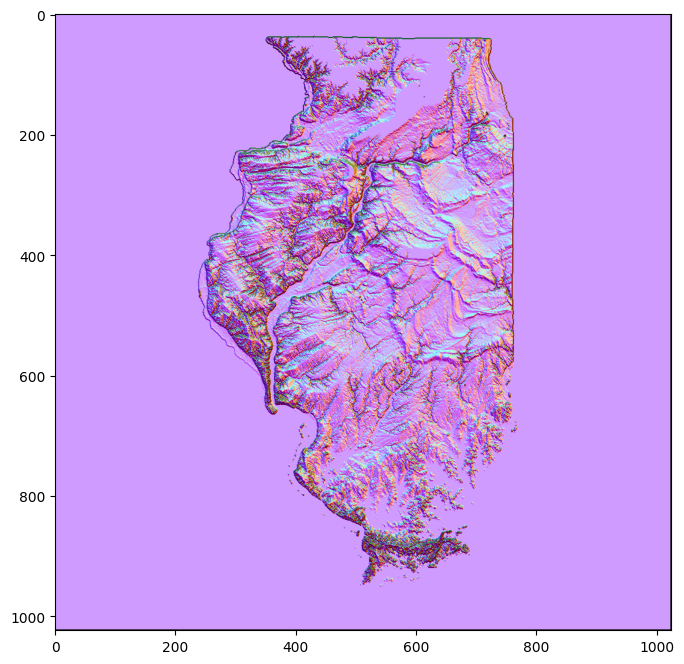

In [5]:
from timeit import default_timer as timer
from ipywidgets import interact, interactive

def draw(exaggeration=30, theta=0, phi=30, k_a=0.2, k_d=0.5, k_s=0.5):
    start = timer()
    out = render(dem, exaggeration, theta, phi, k_a, k_d, k_s)
    end = timer()
    print(f'Render time: {end - start}s', end='\r')
    plt.figure('naive', figsize=(8,8))
    plt.imshow(out)

draw()

100%|███████████████████████████████████████████| 36/36 [00:08<00:00,  4.45it/s]


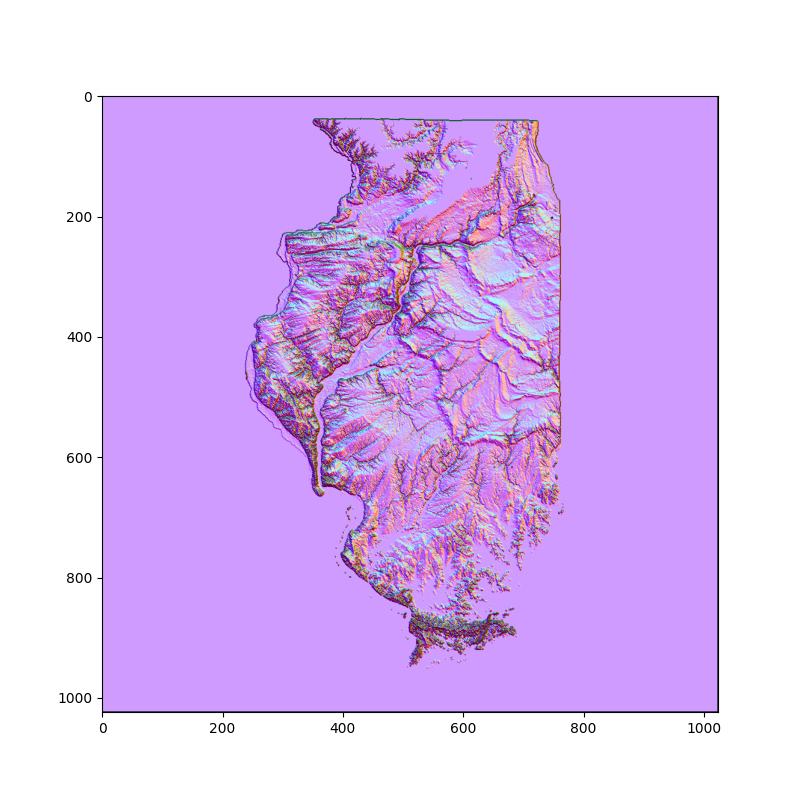

In [13]:
%matplotlib widget

import matplotlib.animation as animation
from tqdm import tqdm

fig, ax = plt.subplots(figsize=(8,8))
ims = []

for theta in tqdm(range(0, 360, 10)):
    ims.append([ax.imshow(render(dem, theta=theta), animated=True)])

ani = animation.ArtistAnimation(fig, ims, interval=50, repeat_delay=1000)
plt.show()

In [ ]:
widget = interactive(draw, exaggeration=(0,50), theta=(0,360), phi=(0,90), k_a=(0,1.), k_d=(0,1.), k_s=(0,1.))
widget.children[-1].layout.height = '8in'
widget